In [ ]:
# !/usr/bin/env python3
# yaha pe humne required libraries import kiye hain.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, export_text

In [ ]:
# yaha pe humne ek sample dataset create kiya hai jisme age, order value, delivery days aur churned status hai.
data = {
    'age':          [22, 35, 28, 45, 19, 52, 31, 40, 25, 38],
    'order_value':  [500, 3500, 1200, 4500, 300, 5000, 1800, 3800, 600, 4200],
    'delivery_days':[2, 7, 4, 8, 1, 9, 5, 7, 2, 8],
    'churned':      [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
print(df)

   age  order_value  delivery_days  churned
0   22          500              2        0
1   35         3500              7        1
2   28         1200              4        0
3   45         4500              8        1
4   19          300              1        0
5   52         5000              9        1
6   31         1800              5        0
7   40         3800              7        1
8   25          600              2        0
9   38         4200              8        1


In [ ]:
# yaha pe humne features aur target variable define kiya hai aur data ko training aur test sets me split kiya hai.
X = df[['age', 'order_value', 'delivery_days']]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8, 3)
Test set size: (2, 3)


In [ ]:
# yaha pe humne Decision Tree Classifier model create kiya hai aur usko training data pe fit kiya hai.
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Decision Tree Classifier trained.")

Decision Tree Classifier trained.


In [ ]:
# yaha pe humne test data ke liye predictions generate kiye hain aur actual aur predicted values ka comparison kiya hai.
y_pred = model.predict(X_test)
print("Actual labels:", y_test.values)
print("Predicted labels:", y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the Decision Tree Classifier: {accuracy*100:.2f}%")

Actual labels: [0 1]
Predicted labels: [0 1]

Accuracy of the Decision Tree Classifier: 100.00%


In [ ]:
# yaha pe humne decision tree ke rules ko visualize kiya hai.
tree_rules = export_text(model, 
                         feature_names=['age', 'order_value', 'delivery_days'])
print("Decision Tree Rules:")
print(tree_rules)

Decision Tree Rules:
|--- order_value <= 2800.00
|   |--- class: 0
|--- order_value >  2800.00
|   |--- class: 1



In [ ]:
# yaha pe humne confusion matrix generate kiya hai aur usko visualize kiya hai.
naya_customer = pd.DataFrame({
    'age': [34],
    'order_value': [2700],
    'delivery_days': [4]
})
naya_customer_pred = model.predict(naya_customer)
print(naya_customer_pred)

[0]


Model Train Ho Gaya Hai!

Decision: Candidate ko Interview ke liye SELECT kar liya jaye! 🎉


C:\Users\Noman\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


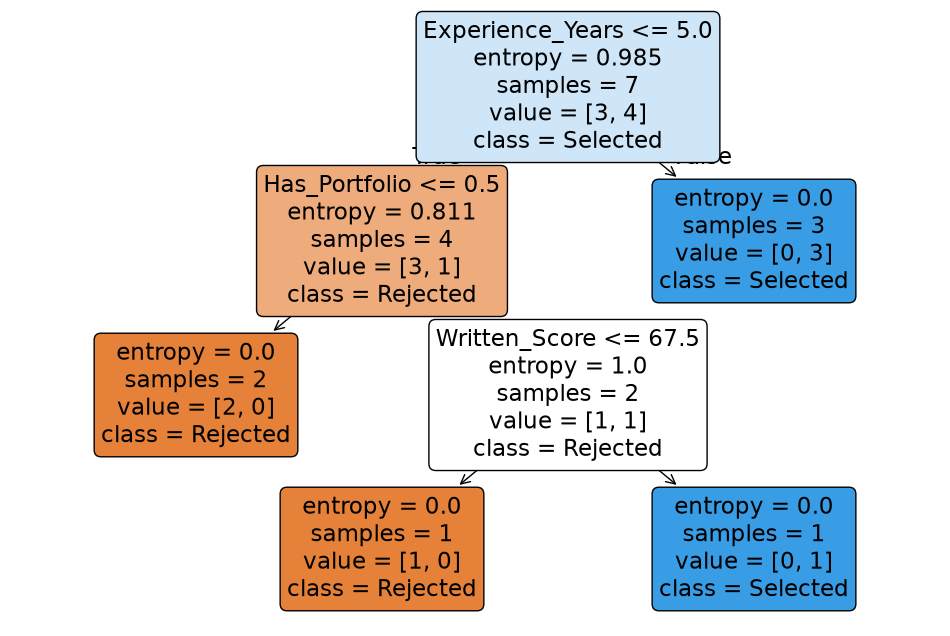

Experience_Years: 52.9%
Written_Score: 29.0%
Has_Portfolio: 18.1%


In [ ]:
# yaha pe humne confusion matrix ko visualize karne ke liye required libraries import kiye hain.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Dummy Data banana (10 Candidates ka record)
data = {
    'Experience_Years': [1, 5, 3, 0, 8, 2, 6, 4, 1, 7],
    'Written_Score':    [60, 85, 70, 90, 80, 50, 95, 65, 80, 75],
    'Has_Portfolio':    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    'Selected':         [0, 1, 1, 0, 1, 0, 1, 0, 1, 1]  # Target (0 = No, 1 = Yes)
}

df = pd.DataFrame(data)

# 2. Features (X) aur Target (y) alag karna
X = df[['Experience_Years', 'Written_Score', 'Has_Portfolio']]
y = df['Selected']

# 3. Data ko Train aur Test mein split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Decision Tree Model banana aur train karna
# max_depth=3 rakha hai taake tree bohat lamba hokar ratta (overfit) na mare
model = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

print("Model Train Ho Gaya Hai!\n")

# 5. Ek Naye Candidate par test karna
# Candidate: 3 saal experience, 78 Written Score, Portfolio hai (1)
naya_candidate = np.array([[1, 95, 1]])
prediction = model.predict(naya_candidate)

if prediction[0] == 1:
    print("Decision: Candidate ko Interview ke liye SELECT kar liya jaye! 🎉")
else:
    print("Decision: Sorry, Candidate reject ho gaya hai. ❌")



# Tree ko visually plot karne ke liye
plt.figure(figsize=(12, 8))
plot_tree(
    model, 
    feature_names=['Experience_Years', 'Written_Score', 'Has_Portfolio'], 
    class_names=['Rejected', 'Selected'], 
    filled=True, 
    rounded=True
)
plt.show()


# Har feature ki ahmiyat (importance) check karna
importances = model.feature_importances_

# Isko saaf shakal mein print karna
for feature, importance in zip(['Experience_Years', 'Written_Score', 'Has_Portfolio'], importances):
    print(f"{feature}: {importance * 100:.1f}%")

In [ ]:
# yaha pe humne required libraries import kiye hain or data ko load kiya hai. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Clear pattern hona chahiye:
# Zyada study + zyada attendance = pass
# Kam study + kam attendance = fail

data = {
    'study_hours': [1, 2, 8, 9, 3, 7, 2, 8, 1, 9,
                    2, 8, 3, 7, 1, 9, 2, 8, 3, 7],
    'attendance':  [20, 30, 90, 95, 40, 85, 25, 92, 15, 98,
                    30, 88, 45, 82, 20, 96, 35, 90, 40, 85],
    'passed':      [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
                    0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
print(df)
df.info()
df.describe()
df.shape
df.isnull().sum()

    study_hours  attendance  passed
0             1          20       0
1             2          30       0
2             8          90       1
3             9          95       1
4             3          40       0
5             7          85       1
6             2          25       0
7             8          92       1
8             1          15       0
9             9          98       1
10            2          30       0
11            8          88       1
12            3          45       0
13            7          82       1
14            1          20       0
15            9          96       1
16            2          35       0
17            8          90       1
18            3          40       0
19            7          85       1
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   study_hours  20 non-null     int64
 1   attendance   20 non-null    

study_hours    0
attendance     0
passed         0
dtype: int64

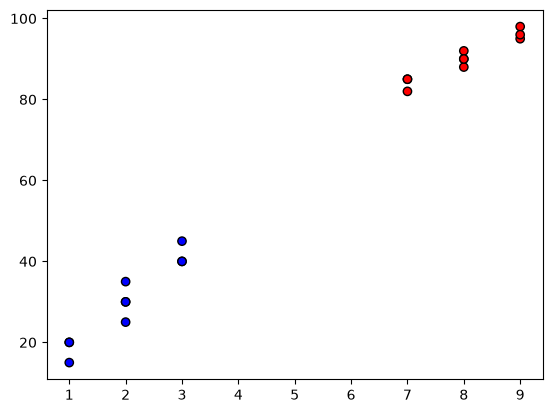

In [ ]:
# yaha pe humne data ko visualize kiya hai aur study_hours aur attendance ke beech ka relationship dekha hai.
df.groupby('passed')['study_hours'].mean()
plt.scatter(df['study_hours'], df['attendance'], c=df['passed'], cmap='bwr', edgecolor='k')
plt.show()

In [ ]:
# yaha pe humne correlation matrix generate kiya hai jisse hum features ke beech ka relationship samajh sakein.
df.corr()

,study_hours,attendance,passed
study_hours,1.000000,0.994612,0.968246
attendance,0.994612,1.000000,0.969684
passed,0.968246,0.969684,1.000000


In [ ]:
# yaha pe humne features aur target variable define kiya hai aur data ko training aur test sets me split kiya hai.
X = df[['study_hours', 'attendance']]
y = df['passed']

X_train,X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16, 2)
Test set size: (4, 2)


In [ ]:
# yaha pe humne Decision Tree Classifier model create kiya hai aur usko training data pe fit kiya hai.
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

print("Decision Tree Classifier trained.")

Decision Tree Classifier trained.


In [ ]:
# yaha pe humne test data ke liye predictions generate kiye hain aur actual aur predicted values ka comparison kiya hai.
y_pred = model.predict(X_test)
print("Actual labels:", y_test.values)
print("Predicted labels:", y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")


Actual labels: [0 1 1 0]
Predicted labels: [0 1 1 0]

Accuracy: 100.00%


In [ ]:
# yaha pe humne importance of each feature ko print kiya hai jisse hum samajh sakein ki kaunsa feature model ke liye zyada important hai.
features = ['study_hours', 'attendance']
for feature,importance in zip(features, model.feature_importances_):
    print(f"{feature}: {importance * 100:.1f}%")q

Decision Tree Rules:
|--- study_hours <= 5.00
|   |--- class: 0
|--- study_hours >  5.00
|   |--- class: 1

study_hours: 100.0%
attendance: 0.0%


In [58]:
naya_student = pd.DataFrame({
    'study_hours': [5],
    'attendance': [70]
})
model.predict(naya_student)
if model.predict(naya_student)[0] == 1:
    print("Decision: Student ko PASS kar diya jaye! 🎉")
else:
    print("Decision: Student ko FAIL kar diya jaye! 🚫")


Decision: Student ko FAIL kar diya jaye! 🚫


In [59]:
tree_rules = export_text(model, feature_names=['study_hours', 'attendance'])
print("Decision Tree Rules:")
print(tree_rules)

Decision Tree Rules:
|--- study_hours <= 5.00
|   |--- class: 0
|--- study_hours >  5.00
|   |--- class: 1



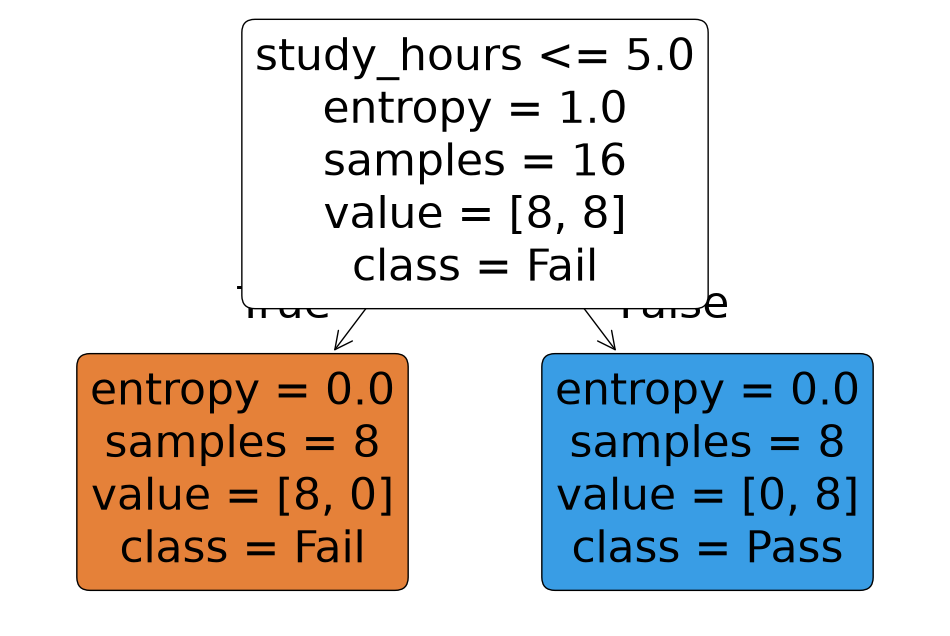

In [60]:
# Tree ko visually plot karna
plt.figure(figsize=(12, 8))
plot_tree(
    model, 
    feature_names=['study_hours', 'attendance'], 
    class_names=['Fail', 'Pass'], 
    filled=True, 
    rounded=True
)
plt.show()